# 03 · Risk: Volatility, Drawdowns, Beta, VaR & the COVID Crash

**Business question:** *How risky were these stocks, and were their returns worth the risk?*

Return alone is half the story. Two stocks with the same 15% CAGR are not equal if one fell 60% on the way.

**New skills today**
- Core risk metrics: **volatility, max drawdown, beta, Value at Risk (VaR), CVaR**
- Risk-adjusted performance: **Sharpe and Sortino ratios**
- Writing **reusable functions** in a Python module (`src/metrics.py`), then using them in the notebook (and later the dashboard)
- A crisis case study: the **COVID-19 crash**

In [1]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append("../src")
from chart_style import apply_style, save, pct_axis, COLORS
import metrics as m                                   # our own module of risk functions
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "portfolio.duckdb"), read_only=True)
returns = (con.sql("SELECT date, name, daily_return FROM marts.daily_returns").df()
              .pivot(index="date", columns="name", values="daily_return"))
returns.index = pd.to_datetime(returns.index)
returns = returns.iloc[1:]                             # drop the first day (no previous close → no return)

BENCH, EW = "Nifty 50 Index", "Equal-weight portfolio"
returns[EW] = returns.drop(columns=BENCH).mean(axis=1)  # the equal-weight portfolio from notebook 02
print(f"{returns.shape[0]:,} trading days × {returns.shape[1]} series · risk-free rate assumed {m.RISK_FREE:.0%}")

2,643 trading days × 29 series · risk-free rate assumed 6%


Open `src/metrics.py` to see the functions: each is only a few lines, and each has a comment explaining the formula.
Putting them in a module means the notebook and the dashboard use **exactly the same calculations**, with no copy-paste errors.

## 1. Volatility: how much does it swing?
**Volatility** = standard deviation of daily returns × √252 (annualised). Roughly: in a "normal" year, returns land within ±1 volatility of the average about two-thirds of the time.

In [2]:
vol = m.volatility(returns).sort_values()
print(f"Nifty 50 volatility: {vol[BENCH]:.1%} · equal-weight portfolio: {vol[EW]:.1%}")
print(f"Average single stock: {vol.drop([BENCH, EW]).mean():.1%} (most volatile: {vol.idxmax()} {vol.max():.0%})")

Nifty 50 volatility: 16.1% · equal-weight portfolio: 15.0%
Average single stock: 27.2% (most volatile: Bajaj Finance 36%)


**Finding:** a single stock swings about **27%** a year on average, but the Nifty (16%) and our equal-weight portfolio (15%) swing far less.
That's **diversification**: individual stocks' ups and downs partly cancel out.

### Are returns "normal"? The fat-tails problem
Many risk models assume returns follow a bell curve (normal distribution). Under that assumption, a move beyond **3 standard deviations** should happen on only ~0.27% of days.

Nifty days beyond ±3σ: actual 37 vs 7 expected if returns were normal (5.2x more)


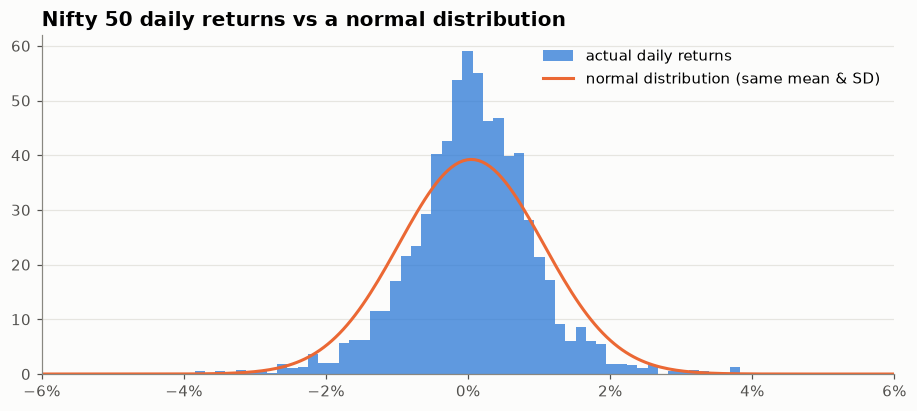

In [3]:
n = returns[BENCH]
z = (n - n.mean()) / n.std()
actual, expected = (z.abs() > 3).sum(), len(n) * 0.0027
print(f"Nifty days beyond ±3σ: actual {actual} vs {expected:.0f} expected if returns were normal ({actual / expected:.1f}x more)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(n, bins=150, density=True, color=COLORS["blue"], alpha=0.75, label="actual daily returns")
x = np.linspace(n.min(), n.max(), 400)
ax.plot(x, stats.norm.pdf(x, n.mean(), n.std()), color=COLORS["orange"], label="normal distribution (same mean & SD)")
ax.set_xlim(-0.06, 0.06); pct_axis(ax, axis="x")
ax.set_title("Nifty 50 daily returns vs a normal distribution")
ax.legend()
save(fig, "08_fat_tails")
plt.show()

**Finding:** extreme days happen **~5× more often** than a bell curve predicts ("fat tails"), and the middle is more peaked.
Models that assume normality **underestimate crash risk**. That's why we use *historical* VaR below instead of a formula.

## 2. Risk vs return: the key picture
Each dot is one stock. Up = more return, right = more risk. The ideal is **top-left**: high return for low risk.

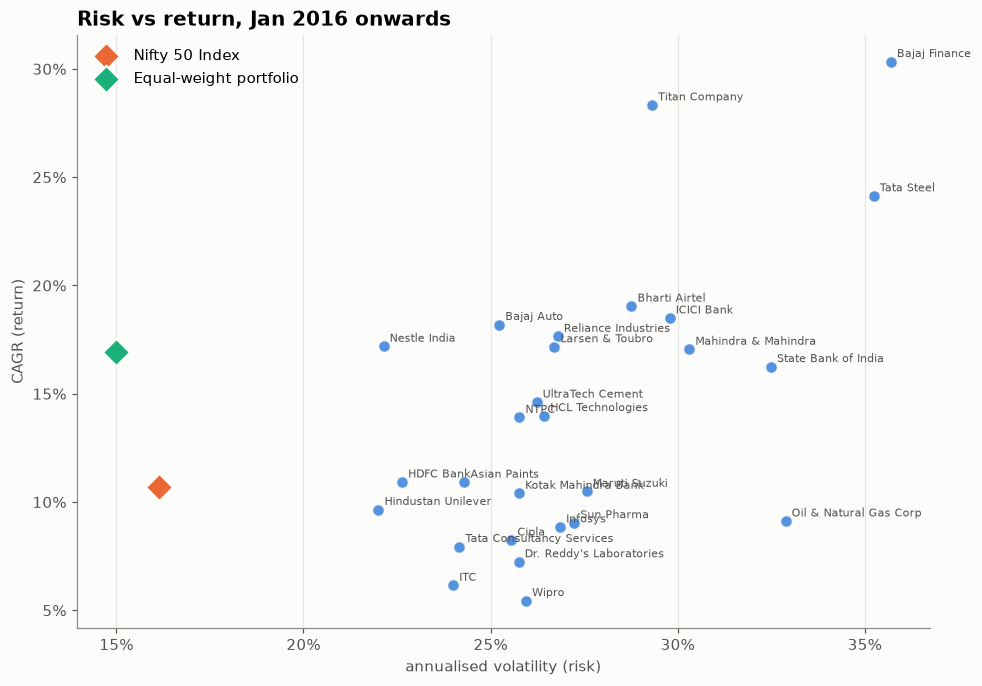

In [4]:
cg = m.cagr(returns)
fig, ax = plt.subplots(figsize=(10, 7))
stocks = [c for c in returns.columns if c not in (BENCH, EW)]
ax.scatter(vol[stocks], cg[stocks], s=60, color=COLORS["blue"], alpha=0.8, edgecolor="#fcfcfb", linewidth=1)
for name in stocks:
    ax.annotate(name, (vol[name], cg[name]), xytext=(4, 3), textcoords="offset points", fontsize=7.5, color="#52514e")
for name, col in [(BENCH, COLORS["orange"]), (EW, COLORS["aqua"])]:
    ax.scatter(vol[name], cg[name], s=160, color=col, marker="D", edgecolor="#fcfcfb", linewidth=1.5, label=name, zorder=3)
pct_axis(ax, axis="x"); pct_axis(ax, axis="y")
ax.set_xlabel("annualised volatility (risk)"); ax.set_ylabel("CAGR (return)")
ax.grid(axis="both")
ax.set_title("Risk vs return, Jan 2016 onwards")
ax.legend(loc="upper left")
save(fig, "09_risk_vs_return")
plt.show()

**Finding:** the two diamonds sit far **left** of every single stock. The index and the equal-weight portfolio carry *much less risk* than any individual stock.
Among stocks, higher risk did **not** reliably mean higher return: ONGC and SBI were very volatile with average returns, while Nestle and Titan earned strong returns with moderate risk.

## 3. Drawdowns: the pain an investor actually feels
**Drawdown** = how far the value is below its previous peak. **Max drawdown** = the worst peak-to-trough fall. Investors panic-sell in drawdowns, so this is the risk people *feel*.

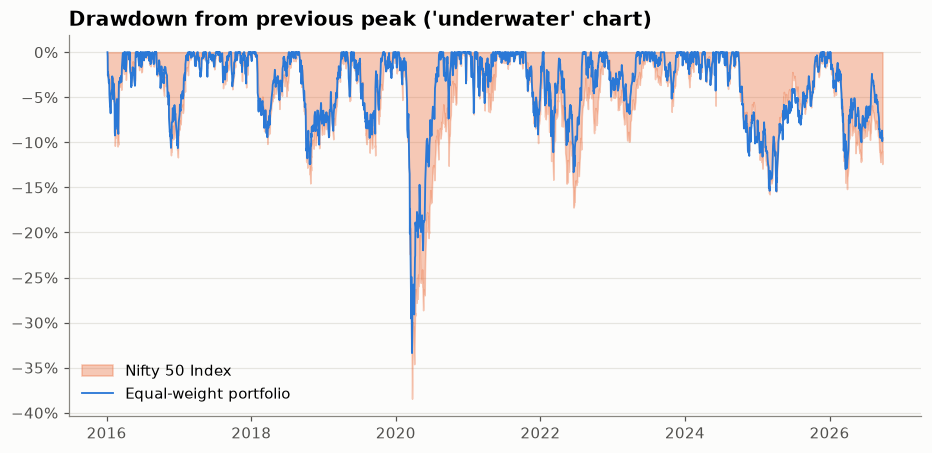

Nifty max drawdown -38.4%: peak 2020-01-14 → trough 2020-03-23 (69 days down) → recovered 2020-11-09 (231 days to recover)


In [5]:
dd = m.drawdown(returns[[BENCH, EW]])
fig, ax = plt.subplots()
ax.fill_between(dd.index, dd[BENCH], 0, color=COLORS["orange"], alpha=0.35, label=BENCH)
ax.plot(dd.index, dd[EW], color=COLORS["blue"], linewidth=1.2, label=EW)
pct_axis(ax)
ax.set_title("Drawdown from previous peak ('underwater' chart)")
ax.legend(loc="lower left")
save(fig, "10_drawdowns")
plt.show()

g = m.growth(returns[BENCH])
trough = dd[BENCH].idxmin()
peak = g[:trough].idxmax()
recovery = g[trough:][g[trough:] >= g[peak]].index[0]
print(f"Nifty max drawdown {dd[BENCH].min():.1%}: peak {peak.date()} → trough {trough.date()} "
      f"({(trough - peak).days} days down) → recovered {recovery.date()} ({(recovery - trough).days} days to recover)")

In [6]:
mdd = m.max_drawdown(returns).sort_values()
pd.DataFrame({"max drawdown": mdd.map("{:.0%}".format)}).head(6)

,max drawdown
name,
Mahindra & Mahindra,-72%
Oil & Natural Gas Corp,-70%
Tata Steel,-64%
Bajaj Finance,-62%
Sun Pharma,-62%
State Bank of India,-59%


**Finding:** the Nifty's worst fall was **−38%** in the COVID crash. It took **~2 months to fall** and **~7.5 months to recover**.
Single stocks were far worse: **M&M −72%, ONGC −70%, Tata Steel −64%, Bajaj Finance −62%** at their worst. Even the biggest winner (Bajaj Finance) put investors through a >60% loss.

## 4. Beta: how much a stock moves with the market
**Beta** = covariance(stock, market) ÷ variance(market). It's the slope when you plot the stock's daily returns against the market's.
- β > 1 → amplifies market moves (aggressive) · β < 1 → dampens them (defensive) · β = 1 → moves like the market

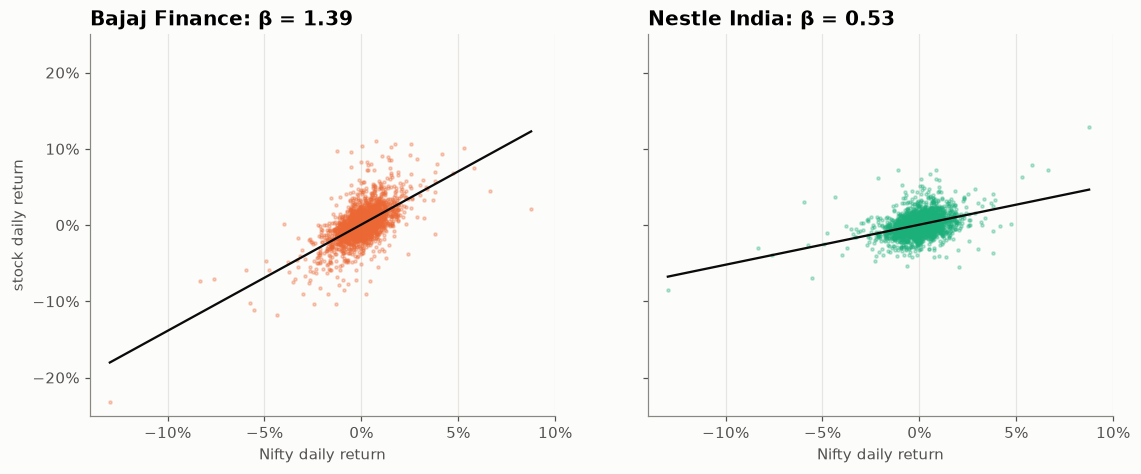

Most defensive (lowest beta): Cipla 0.48, Dr. Reddy's Laboratories 0.49, Nestle India 0.53
Most aggressive (highest beta): State Bank of India 1.30, Tata Steel 1.31, Bajaj Finance 1.39


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name, col in [(axes[0], "Bajaj Finance", COLORS["orange"]), (axes[1], "Nestle India", COLORS["aqua"])]:
    x, y = returns[BENCH], returns[name]
    slope, intercept, r_value, *_ = stats.linregress(x, y)       # simple linear regression
    ax.scatter(x, y, s=4, alpha=0.3, color=col)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, intercept + slope * xs, color="#0b0b0b", linewidth=1.5)
    ax.set_title(f"{name}: β = {slope:.2f}")
    ax.set_xlim(-0.14, 0.10); ax.set_ylim(-0.25, 0.25)
    pct_axis(ax, axis="x"); pct_axis(ax, axis="y"); ax.grid(axis="both")
    ax.set_xlabel("Nifty daily return")
axes[0].set_ylabel("stock daily return")
save(fig, "11_beta_examples")
plt.show()

betas = m.beta(returns.drop(columns=[BENCH, EW]), returns[BENCH]).sort_values()
print("Most defensive (lowest beta):", ", ".join(f"{k} {v:.2f}" for k, v in betas.head(3).items()))
print("Most aggressive (highest beta):", ", ".join(f"{k} {v:.2f}" for k, v in betas.tail(3).items()))

**Finding:** **Bajaj Finance, Tata Steel, SBI and ICICI Bank (β ≈ 1.3–1.4)** amplify market moves by 30–40%, while HDFC and Kotak (β ≈ 1.0) move with the market. **Pharma (Cipla, Dr. Reddy's) and FMCG (Nestle, HUL)** have β ≈ 0.5–0.6,
so they fall much less when the market falls. Beta tells a portfolio manager how to dial market exposure up or down.

## 5. Value at Risk (VaR) & Expected Shortfall
**1-day 95% VaR** answers: *"On a bad day (the worst 5%), how much could I lose?"* Historical VaR simply takes the 5th-percentile daily return.
**CVaR (Expected Shortfall)** answers the follow-up: *"And when it's worse than that, how bad on average?"*

In [8]:
portfolio_value = 10_00_000     # ₹10 lakh
for name in [BENCH, EW]:
    v, cv = m.var_historical(returns[name]), m.cvar_historical(returns[name])
    print(f"{name:<24} 95% 1-day VaR {v:.2%} (₹{v * portfolio_value:,.0f})   CVaR {cv:.2%} (₹{cv * portfolio_value:,.0f})")

# Backtest: a correct 95% VaR should be exceeded on about 5% of days
breaches = (returns[BENCH] < -m.var_historical(returns[BENCH])).mean()
print(f"\nDays the Nifty lost more than its VaR: {breaches:.1%} (should be ~5%)")

Nifty 50 Index           95% 1-day VaR 1.43% (₹14,286)   CVaR 2.34% (₹23,428)
Equal-weight portfolio   95% 1-day VaR 1.34% (₹13,353)   CVaR 2.12% (₹21,207)

Days the Nifty lost more than its VaR: 5.0% (should be ~5%)


**Finding:** for a ₹10 lakh Nifty portfolio, on 1 day in 20 you should expect to lose **more than ~₹14,000**, and on those bad days the average loss is **~₹23,000**.
CVaR is ~60% bigger than VaR, which is the fat tails again: when it's bad, it's *really* bad.
*(Caveat: this "backtest" uses the same data the VaR was computed from, so it's a sanity check. A real VaR model is estimated on past data and tested on future days.)*

## 6. Risk-adjusted performance: Sharpe & Sortino
- **Sharpe ratio** = (annual return − risk-free rate) ÷ volatility → *return earned per unit of risk*. Above 1 is excellent, 0.5 is decent.
- **Sortino ratio** = same, but divides only by **downside** volatility (investors don't mind upside swings).
- The **risk-free rate** (assumed 6%, close to Indian T-bill yields) is what you'd earn with no risk; only returns above it reward risk-taking.

In [9]:
table = m.summary_table(returns, BENCH).sort_values("Sharpe", ascending=False)
formats = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Max drawdown": "{:.0%}", "Beta": "{:.2f}",
           "VaR 95% (1-day)": "{:.2%}", "CVaR 95% (1-day)": "{:.2%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}"}
display_table = table.copy()
for col, fmt in formats.items():
    display_table[col] = table[col].map(fmt.format)     # turn numbers into nicely formatted text for display
display_table

,CAGR,Volatility,Max drawdown,Beta,VaR 95% (1-day),CVaR 95% (1-day),Sharpe,Sortino
Titan Company,28.3%,29.3%,-42%,0.93,2.50%,3.91%,0.81,1.26
Bajaj Finance,30.3%,35.7%,-62%,1.39,3.15%,5.17%,0.77,1.14
Equal-weight portfolio,16.9%,15.0%,-33%,0.89,1.34%,2.12%,0.74,1.06
Tata Steel,24.1%,35.2%,-64%,1.31,3.28%,5.05%,0.63,0.94
Nestle India,17.2%,22.1%,-23%,0.53,2.01%,2.85%,0.57,0.89
Bajaj Auto,18.2%,25.2%,-42%,0.81,2.27%,3.38%,0.57,0.84
Bharti Airtel,19.0%,28.8%,-47%,0.81,2.61%,3.81%,0.55,0.86
ICICI Bank,18.5%,29.8%,-48%,1.30,2.55%,4.02%,0.53,0.80
Reliance Industries,17.6%,26.8%,-45%,1.08,2.30%,3.50%,0.53,0.80
Larsen & Toubro,17.2%,26.7%,-54%,1.13,2.25%,3.55%,0.52,0.78


**Findings**
- Best risk-adjusted: **Titan (Sharpe ~0.81)**, then **Bajaj Finance (~0.77)**. Bajaj Finance had the highest CAGR but *more risk* per unit of return than Titan.
- The **equal-weight portfolio (~0.74)** beats all but two single stocks and has **2× the Nifty's Sharpe (~0.35)**, the power of diversification (still flattered by survivorship bias).
- **Nestle** ranks high thanks to low volatility and the smallest drawdown (−23%): steady compounding.
- Laggards **ITC, Wipro, Dr. Reddy's and TCS** barely beat the risk-free rate after adjusting for risk (Sharpe < 0.2).

## 7. Risk changes over time: rolling volatility
Risk isn't constant. A **60-day rolling volatility** shows calm periods and storms.

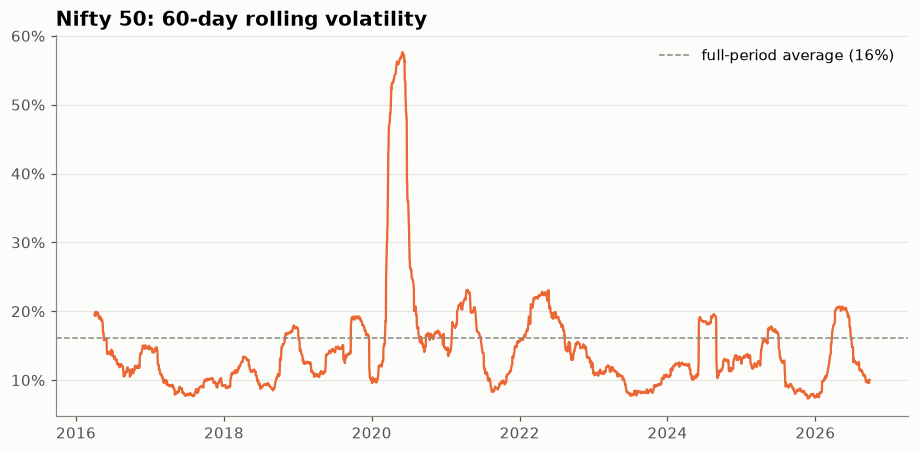

In [10]:
roll_vol = returns[[BENCH]].rolling(60).std() * np.sqrt(252)
fig, ax = plt.subplots()
ax.plot(roll_vol.index, roll_vol[BENCH], color=COLORS["orange"], linewidth=1.5)
ax.axhline(vol[BENCH], color=COLORS["grey"], linestyle="--", linewidth=1, label=f"full-period average ({vol[BENCH]:.0%})")
pct_axis(ax)
ax.set_title("Nifty 50: 60-day rolling volatility")
ax.legend(loc="upper right")
save(fig, "12_rolling_volatility")
plt.show()

**Finding:** volatility spent most of the decade at **10–15%**, but **exploded to nearly 60%** in March–April 2020. Risk comes in bursts ("volatility clustering"),
so a single full-period number understates how bad things can get in a crisis.

## 8. Case study: the COVID-19 crash (Jan–Mar 2020)
The Nifty peaked on **14 Jan 2020** and bottomed on **23 Mar 2020**. How did each stock hold up?

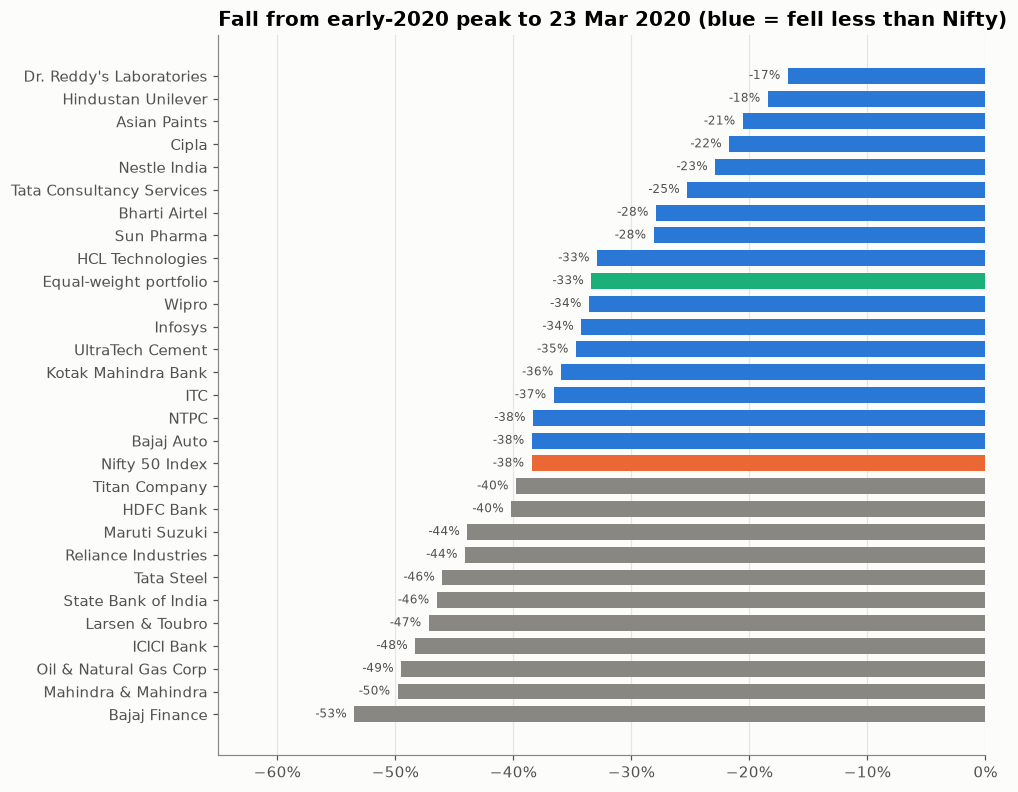

In [11]:
peak_to_trough = (m.growth(returns).loc["2020-03-23"] /
                  m.growth(returns).loc["2020-01-01":"2020-02-20"].max() - 1).sort_values()

fig, ax = plt.subplots(figsize=(9, 8.5))
colors = [COLORS["orange"] if n == BENCH else COLORS["aqua"] if n == EW else
          (COLORS["blue"] if v > peak_to_trough[BENCH] else COLORS["grey"]) for n, v in peak_to_trough.items()]
ax.barh(peak_to_trough.index, peak_to_trough.values, color=colors, height=0.7)
for y, v in enumerate(peak_to_trough.values):
    ax.text(v, y, f"{v:.0%}  ", va="center", ha="right", fontsize=8, color="#52514e")
pct_axis(ax, axis="x"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlim(-0.65, 0)
ax.set_title("Fall from early-2020 peak to 23 Mar 2020 (blue = fell less than Nifty)")
save(fig, "13_covid_crash")
plt.show()

### Diversification fails exactly when you need it
The benefit of diversification depends on stocks **not** moving together. What happened to correlations during the crash?

In [12]:
def avg_pairwise_corr(df):
    c = df.corr().values
    return c[np.triu_indices_from(c, k=1)].mean()     # average of the upper triangle (each pair once)

only_stocks = returns.drop(columns=[BENCH, EW])
calm   = avg_pairwise_corr(only_stocks.loc["2019-01-01":"2019-12-31"])
crisis = avg_pairwise_corr(only_stocks.loc["2020-02-20":"2020-04-30"])
print(f"Average correlation between stocks, calm 2019:          {calm:.2f}")
print(f"Average correlation between stocks, COVID crash period: {crisis:.2f}")

Average correlation between stocks, calm 2019:          0.22
Average correlation between stocks, COVID crash period: 0.60


**Findings**
- The Nifty fell **38%**; **financials and autos fell hardest** (Bajaj Finance −53%, M&M −50%, ICICI −48%).
- **Defensives held up**: HUL (−18%), Dr. Reddy's (−17%), Asian Paints (−21%), Cipla (−22%) and Nestle (−23%) fell about half as much. These are the **low-beta** stocks from section 4, so beta predicted crash behaviour well.
- **Correlations nearly tripled** (≈0.22 → ≈0.60): in a panic, almost everything falls together, so diversification helps least when you need it most.
  → A truly defensive portfolio needs low-beta sectors (pharma, FMCG), not just "more stocks".

---
## Summary: key findings (Risk)
| # | Finding | So what? |
|---|---|---|
| 1 | Single stocks swing ~27%/yr; Nifty 16%, equal-weight portfolio 15% | Diversification cuts risk dramatically |
| 2 | Extreme days happen **~5× more** than a normal distribution predicts | Normal-based models underestimate crash risk; use historical VaR |
| 3 | Nifty max drawdown **−38%** (COVID), recovered in ~7.5 months; single stocks fell up to **−72%** | Drawdown is the risk investors feel |
| 4 | Bajaj Finance, Tata Steel, SBI, ICICI β ≈ 1.3–1.4; pharma/FMCG β ≈ 0.5–0.6 | Beta = a dial for market exposure |
| 5 | Nifty 95% 1-day VaR ≈ 1.4% (₹14k on ₹10L); CVaR ≈ 2.3% | Tail losses are ~60% worse than VaR |
| 6 | Best Sharpe: Titan 0.81, Bajaj Finance 0.77; equal-weight 0.74 vs Nifty 0.35 | Risk-adjusted view changes the ranking |
| 7 | COVID: low-beta defensives fell ~half as much; **correlations 0.22 → 0.60** | Build defence with low-beta sectors, not just more stocks |

Next: notebook 04 uses correlations to **build optimised portfolios** and tests them honestly on data they've never seen.

In [13]:
con.close()